In [65]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Set style for better-looking plots
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
pd.set_option('display.max_columns', None)

# Data Exploration and Visualization

Customer Attrition Classification Dataset

In [66]:
# Load the dataset
df = pd.read_csv('BankChurners.csv')
print(f"Dataset Shape: {df.shape}")
print(f"\nFirst few rows:")
df.head()

Dataset Shape: (10127, 23)

First few rows:


,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2
0,768805383,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,5,1,3,12691.0,777,11914.0,1.335,1144,42,1.625,0.061,0.000093,0.99991
1,818770008,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,6,1,2,8256.0,864,7392.0,1.541,1291,33,3.714,0.105,0.000057,0.99994
2,713982108,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,4,1,0,3418.0,0,3418.0,2.594,1887,20,2.333,0.000,0.000021,0.99998
3,769911858,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,3,4,1,3313.0,2517,796.0,1.405,1171,20,2.333,0.760,0.000134,0.99987
4,709106358,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,5,1,0,4716.0,0,4716.0,2.175,816,28,2.500,0.000,0.000022,0.99998


In [67]:
# Data Info and Missing Values
print("Dataset Info:")
print(df.info())
print("\n" + "="*80)
print("\nMissing Values:")
missing = df.isnull().sum()
if missing.sum() == 0:
    print("No missing values found!")
else:
    print(missing[missing > 0])
    
print("\n" + "="*80)
print("\nData Types:")
print(df.dtypes)

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 23 columns):
 #   Column                                                                                                                              Non-Null Count  Dtype  
---  ------                                                                                                                              --------------  -----  
 0   CLIENTNUM                                                                                                                           10127 non-null  int64  
 1   Attrition_Flag                                                                                                                      10127 non-null  str    
 2   Customer_Age                                                                                                                        10127 non-null  int64  
 3   Gender                                                                        

In [68]:
# Descriptive Statistics
print("Descriptive Statistics (Numerical Features):")
print(df.describe().T)

Descriptive Statistics (Numerical Features):
                                                      count          mean  \
CLIENTNUM                                           10127.0  7.391776e+08   
Customer_Age                                        10127.0  4.632596e+01   
Dependent_count                                     10127.0  2.346203e+00   
Months_on_book                                      10127.0  3.592841e+01   
Total_Relationship_Count                            10127.0  3.812580e+00   
Months_Inactive_12_mon                              10127.0  2.341167e+00   
Contacts_Count_12_mon                               10127.0  2.455317e+00   
Credit_Limit                                        10127.0  8.631954e+03   
Total_Revolving_Bal                                 10127.0  1.162814e+03   
Avg_Open_To_Buy                                     10127.0  7.469140e+03   
Total_Amt_Chng_Q4_Q1                                10127.0  7.599407e-01   
Total_Trans_Amt                

## 1. Target Variable Analysis

Target Variable Distribution (Attrition_Flag):
Attrition_Flag
Existing Customer    8500
Attrited Customer    1627
Name: count, dtype: int64

Percentage Distribution:
Attrition_Flag
Existing Customer    83.934038
Attrited Customer    16.065962
Name: proportion, dtype: float64


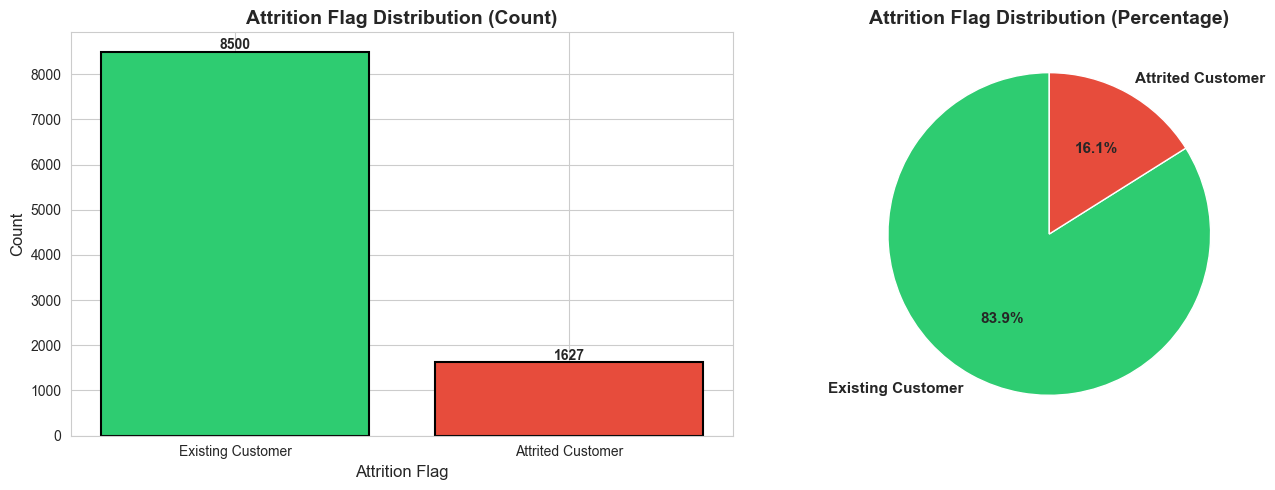


Class Balance:  Imbalanced


In [69]:
# Target Variable Distribution
print("Target Variable Distribution (Attrition_Flag):")
print(df['Attrition_Flag'].value_counts())
print("\nPercentage Distribution:")
print(df['Attrition_Flag'].value_counts(normalize=True) * 100)

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count plot
target_counts = df['Attrition_Flag'].value_counts()
colors = ['#2ecc71', '#e74c3c']
axes[0].bar(target_counts.index, target_counts.values, color=colors, edgecolor='black', linewidth=1.5)
axes[0].set_title('Attrition Flag Distribution (Count)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Count', fontsize=12)
axes[0].set_xlabel('Attrition Flag', fontsize=12)
for i, v in enumerate(target_counts.values):
    axes[0].text(i, v + 50, str(v), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(target_counts.values, labels=target_counts.index, autopct='%1.1f%%', 
            colors=colors, startangle=90, textprops={'fontsize': 11, 'fontweight': 'bold'})
axes[1].set_title('Attrition Flag Distribution (Percentage)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print("\nClass Balance: ", "Balanced" if abs(target_counts.values[0] - target_counts.values[1]) / target_counts.sum() < 0.1 else "Imbalanced")

## 2. Categorical Features Analysis

In [70]:
# Identify categorical columns
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
print(f"Categorical columns: {categorical_cols}\n")

# Display unique values and counts
for col in categorical_cols:
    print(f"\n{col}:")
    print(df[col].value_counts())
    print(f"Number of unique values: {df[col].nunique()}")

Categorical columns: ['Attrition_Flag', 'Gender', 'Education_Level', 'Marital_Status', 'Income_Category', 'Card_Category']


Attrition_Flag:
Attrition_Flag
Existing Customer    8500
Attrited Customer    1627
Name: count, dtype: int64
Number of unique values: 2

Gender:
Gender
F    5358
M    4769
Name: count, dtype: int64
Number of unique values: 2

Education_Level:
Education_Level
Graduate         3128
High School      2013
Unknown          1519
Uneducated       1487
College          1013
Post-Graduate     516
Doctorate         451
Name: count, dtype: int64
Number of unique values: 7

Marital_Status:
Marital_Status
Married     4687
Single      3943
Unknown      749
Divorced     748
Name: count, dtype: int64
Number of unique values: 4

Income_Category:
Income_Category
Less than $40K    3561
$40K - $60K       1790
$80K - $120K      1535
$60K - $80K       1402
Unknown           1112
$120K +            727
Name: count, dtype: int64
Number of unique values: 6

Card_Category:
Card_Category
B

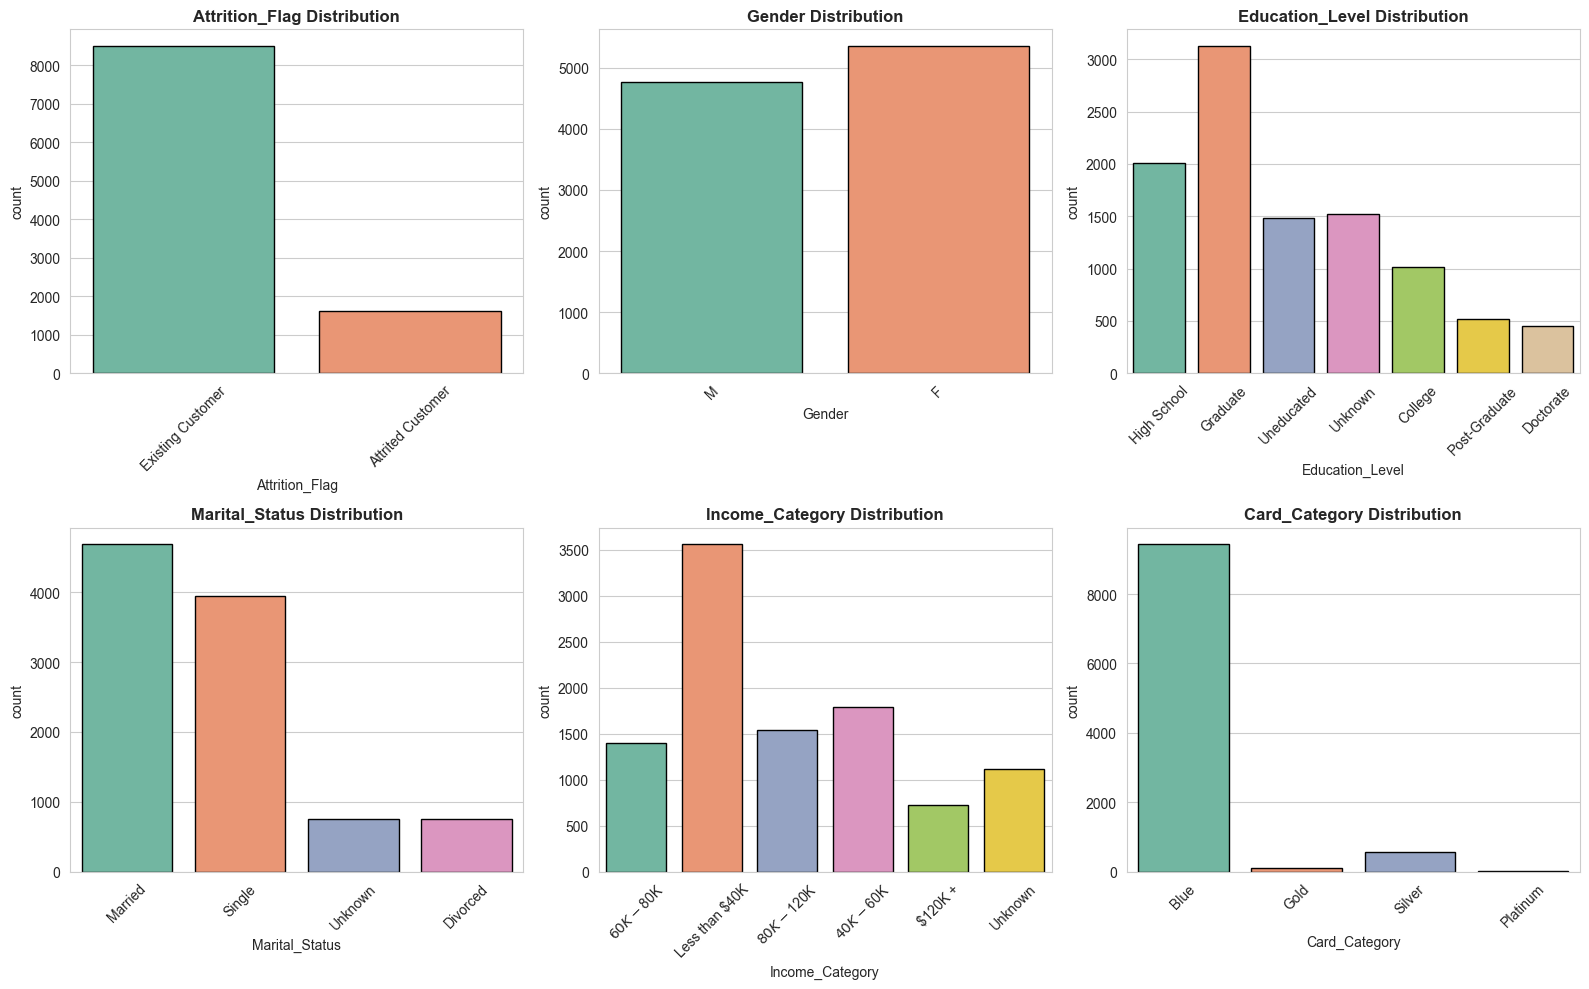

In [71]:
# Visualize categorical features (excluding CLIENTNUM and long feature names)
exclude_cols = ['CLIENTNUM', 'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1',
                'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2']

cat_features = [col for col in categorical_cols if col not in exclude_cols]
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.ravel()

for idx, col in enumerate(cat_features):
    sns.countplot(data=df, x=col, ax=axes[idx], palette='Set2', edgecolor='black')
    axes[idx].set_title(f'{col} Distribution', fontsize=12, fontweight='bold')
    axes[idx].tick_params(axis='x', rotation=45)

# Remove the last empty subplot
if len(cat_features) < len(axes):
    fig.delaxes(axes[-1])

plt.tight_layout()
plt.show()

## 3. Numerical Features Analysis

In [72]:
# Identify numerical columns
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
# Exclude ID and Naive Bayes classifier columns
numerical_cols = [col for col in numerical_cols if col not in ['CLIENTNUM', 
                                                                'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1',
                                                                'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2']]
print(f"Numerical columns ({len(numerical_cols)}): {numerical_cols}")

Numerical columns (14): ['Customer_Age', 'Dependent_count', 'Months_on_book', 'Total_Relationship_Count', 'Months_Inactive_12_mon', 'Contacts_Count_12_mon', 'Credit_Limit', 'Total_Revolving_Bal', 'Avg_Open_To_Buy', 'Total_Amt_Chng_Q4_Q1', 'Total_Trans_Amt', 'Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1', 'Avg_Utilization_Ratio']


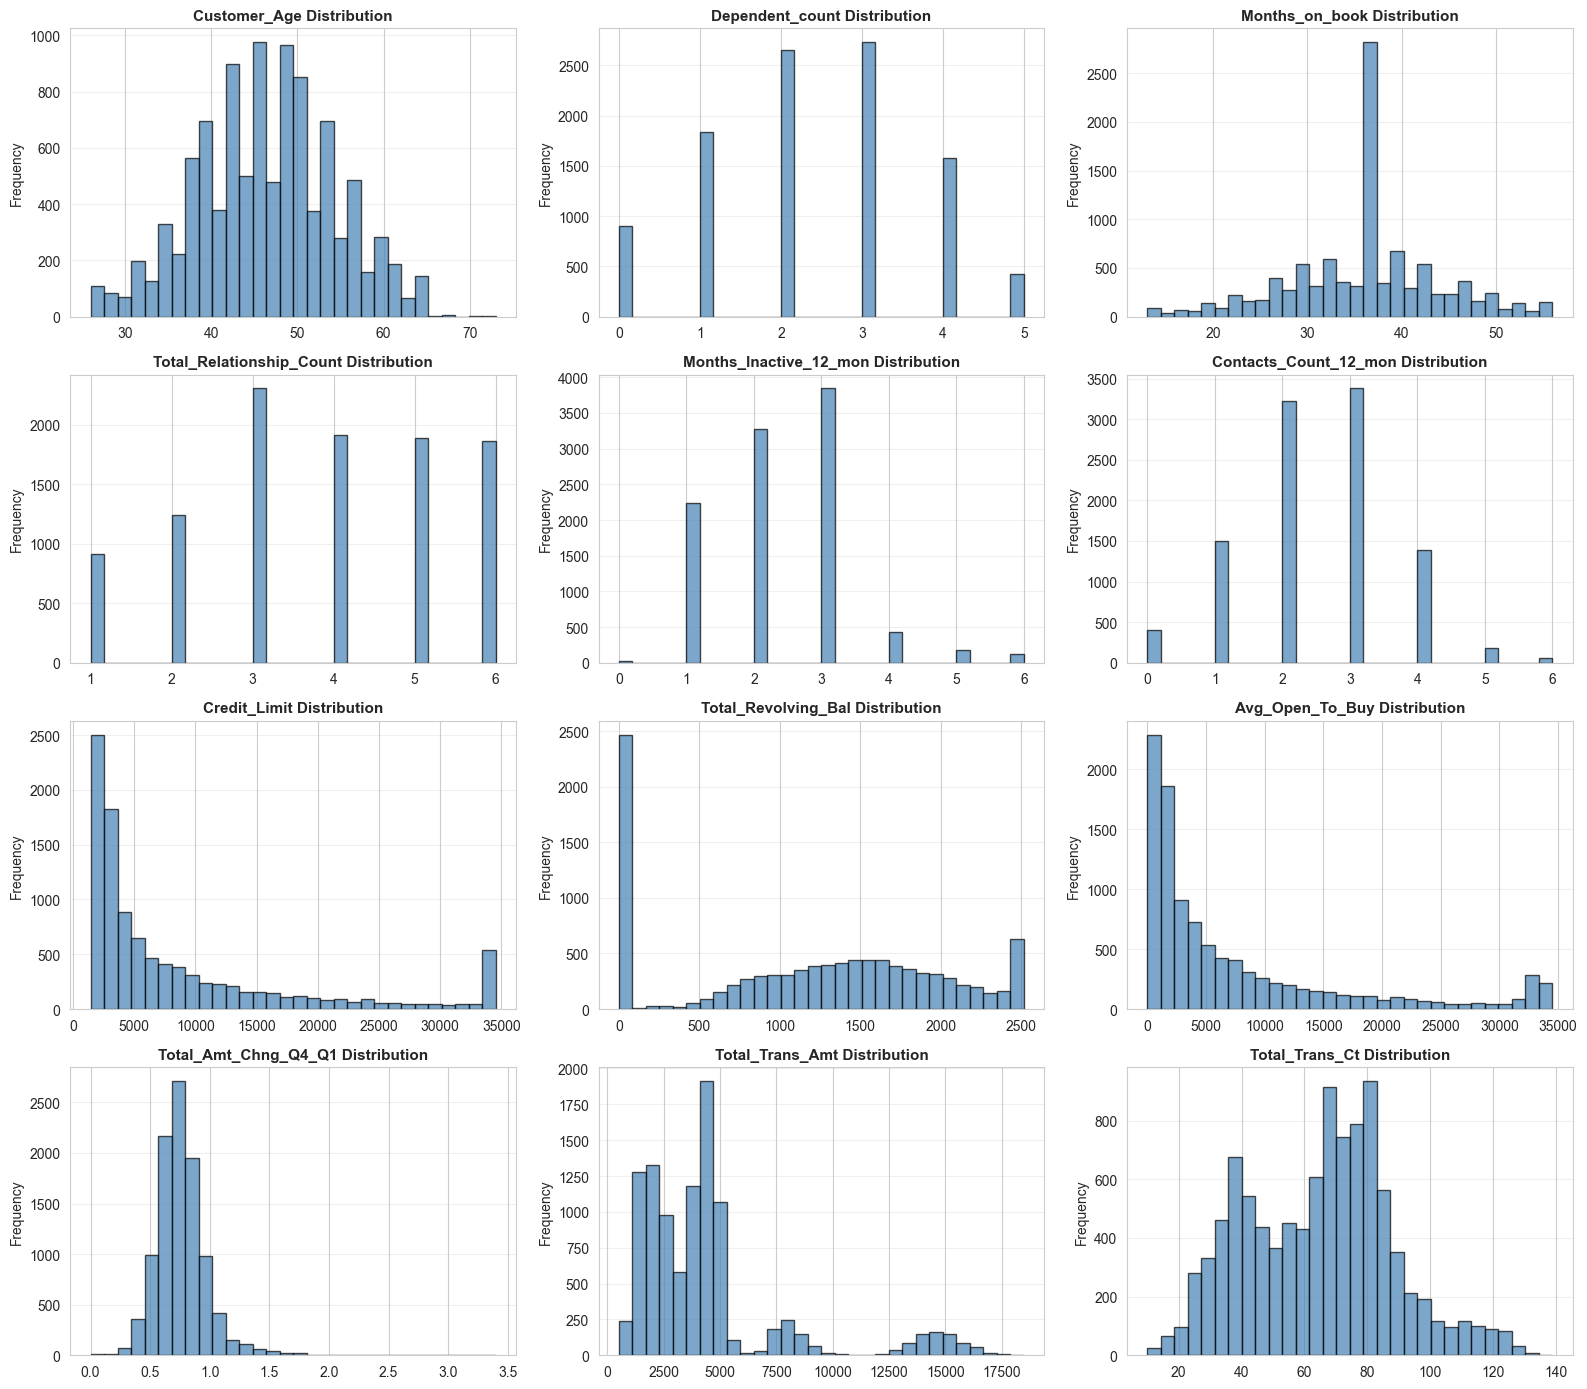

In [73]:
# Distribution plots for numerical features (first 12)
fig, axes = plt.subplots(4, 3, figsize=(16, 14))
axes = axes.ravel()

for idx, col in enumerate(numerical_cols[:12]):
    axes[idx].hist(df[col], bins=30, color='steelblue', edgecolor='black', alpha=0.7)
    axes[idx].set_title(f'{col} Distribution', fontsize=11, fontweight='bold')
    axes[idx].set_ylabel('Frequency')
    axes[idx].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

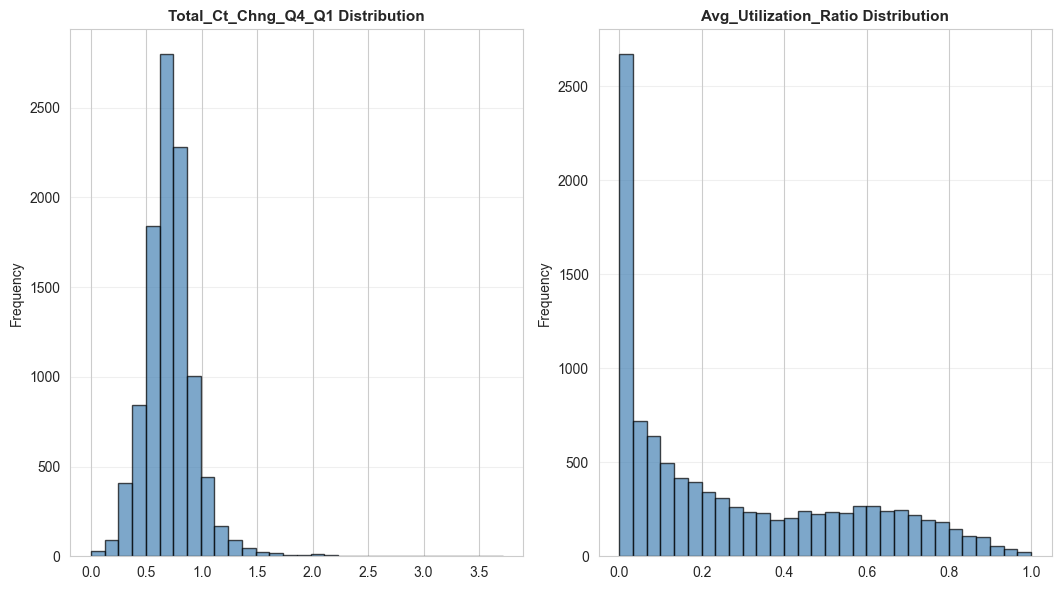

In [74]:
# Distribution plots for remaining numerical features
if len(numerical_cols) > 12:
    remaining = len(numerical_cols) - 12
    fig, axes = plt.subplots((remaining + 2) // 3, 3, figsize=(16, 6))
    axes = axes.ravel()
    
    for idx, col in enumerate(numerical_cols[12:]):
        axes[idx].hist(df[col], bins=30, color='steelblue', edgecolor='black', alpha=0.7)
        axes[idx].set_title(f'{col} Distribution', fontsize=11, fontweight='bold')
        axes[idx].set_ylabel('Frequency')
        axes[idx].grid(axis='y', alpha=0.3)
    
    # Remove empty subplots
    for idx in range(remaining, len(axes)):
        fig.delaxes(axes[idx])
    
    plt.tight_layout()
    plt.show()

## 4. Bivariate Analysis: Numerical Features vs Target Variable

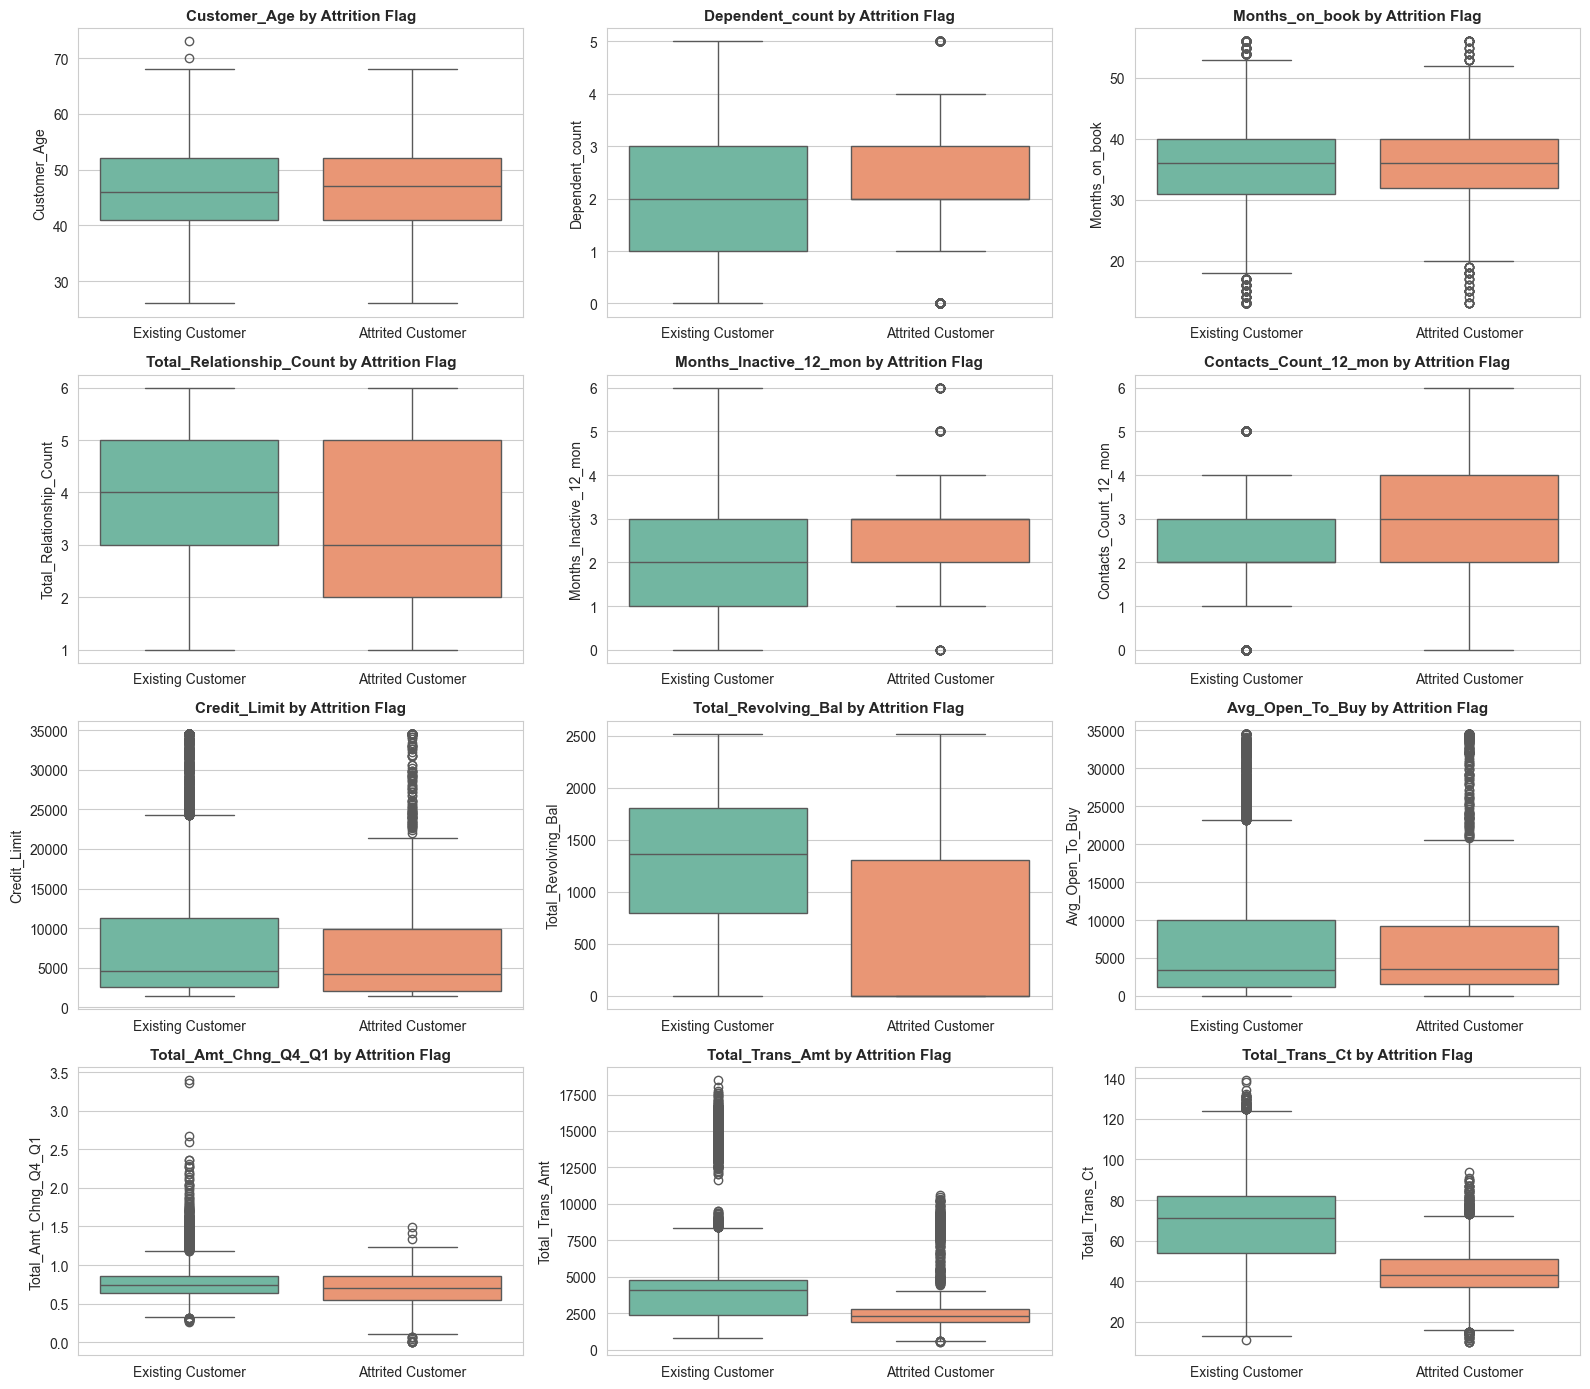

In [75]:
# Box plots: Numerical features vs Attrition Flag (first 12)
fig, axes = plt.subplots(4, 3, figsize=(16, 14))
axes = axes.ravel()

for idx, col in enumerate(numerical_cols[:12]):
    sns.boxplot(data=df, x='Attrition_Flag', y=col, ax=axes[idx], palette='Set2')
    axes[idx].set_title(f'{col} by Attrition Flag', fontsize=11, fontweight='bold')
    axes[idx].set_xlabel('')

plt.tight_layout()
plt.show()

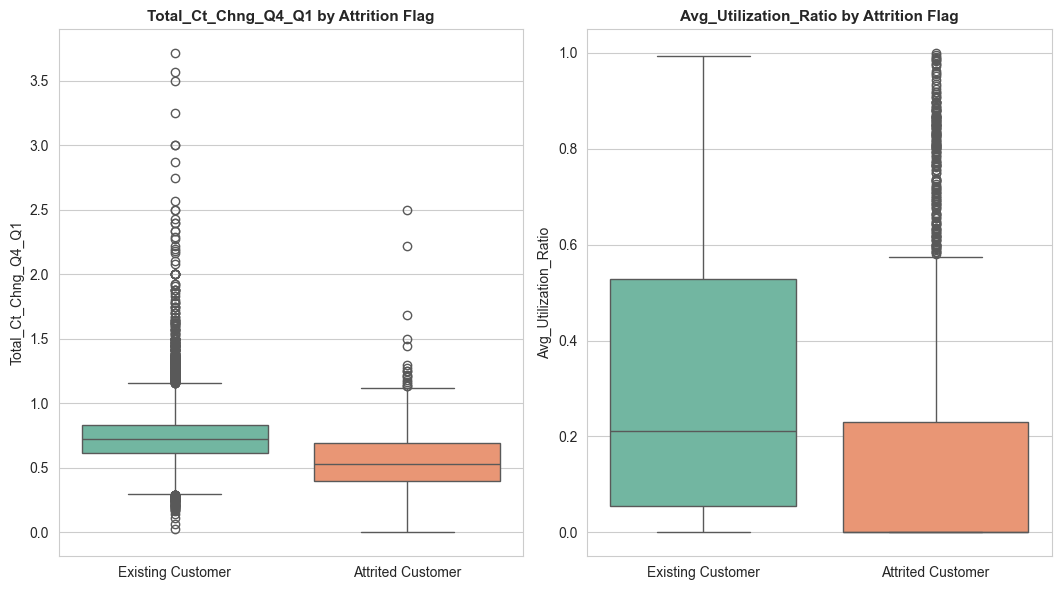

In [76]:
# Box plots for remaining numerical features
if len(numerical_cols) > 12:
    remaining = len(numerical_cols) - 12
    fig, axes = plt.subplots((remaining + 2) // 3, 3, figsize=(16, 6))
    axes = axes.ravel()
    
    for idx, col in enumerate(numerical_cols[12:]):
        sns.boxplot(data=df, x='Attrition_Flag', y=col, ax=axes[idx], palette='Set2')
        axes[idx].set_title(f'{col} by Attrition Flag', fontsize=11, fontweight='bold')
        axes[idx].set_xlabel('')
    
    # Remove empty subplots
    for idx in range(remaining, len(axes)):
        fig.delaxes(axes[idx])
    
    plt.tight_layout()
    plt.show()

## 5. Categorical Features vs Target Variable

In [77]:
# Cross-tabulation and Chi-square analysis
print("Categorical Features vs Attrition Flag:\n")
for col in cat_features:
    print(f"\n{col}:")
    crosstab = pd.crosstab(df[col], df['Attrition_Flag'], margins=True)
    print(crosstab)
    
    # Calculate percentages
    pct_crosstab = pd.crosstab(df[col], df['Attrition_Flag'], normalize='index') * 100
    print(f"\nPercentage by {col}:")
    print(pct_crosstab.round(2))

Categorical Features vs Attrition Flag:


Attrition_Flag:
Attrition_Flag     Attrited Customer  Existing Customer    All
Attrition_Flag                                                
Attrited Customer               1627                  0   1627
Existing Customer                  0               8500   8500
All                             1627               8500  10127

Percentage by Attrition_Flag:
Attrition_Flag     Attrited Customer  Existing Customer
Attrition_Flag                                         
Attrited Customer              100.0                0.0
Existing Customer                0.0              100.0

Gender:
Attrition_Flag  Attrited Customer  Existing Customer    All
Gender                                                     
F                             930               4428   5358
M                             697               4072   4769
All                          1627               8500  10127

Percentage by Gender:
Attrition_Flag  Attrited Customer  Exist

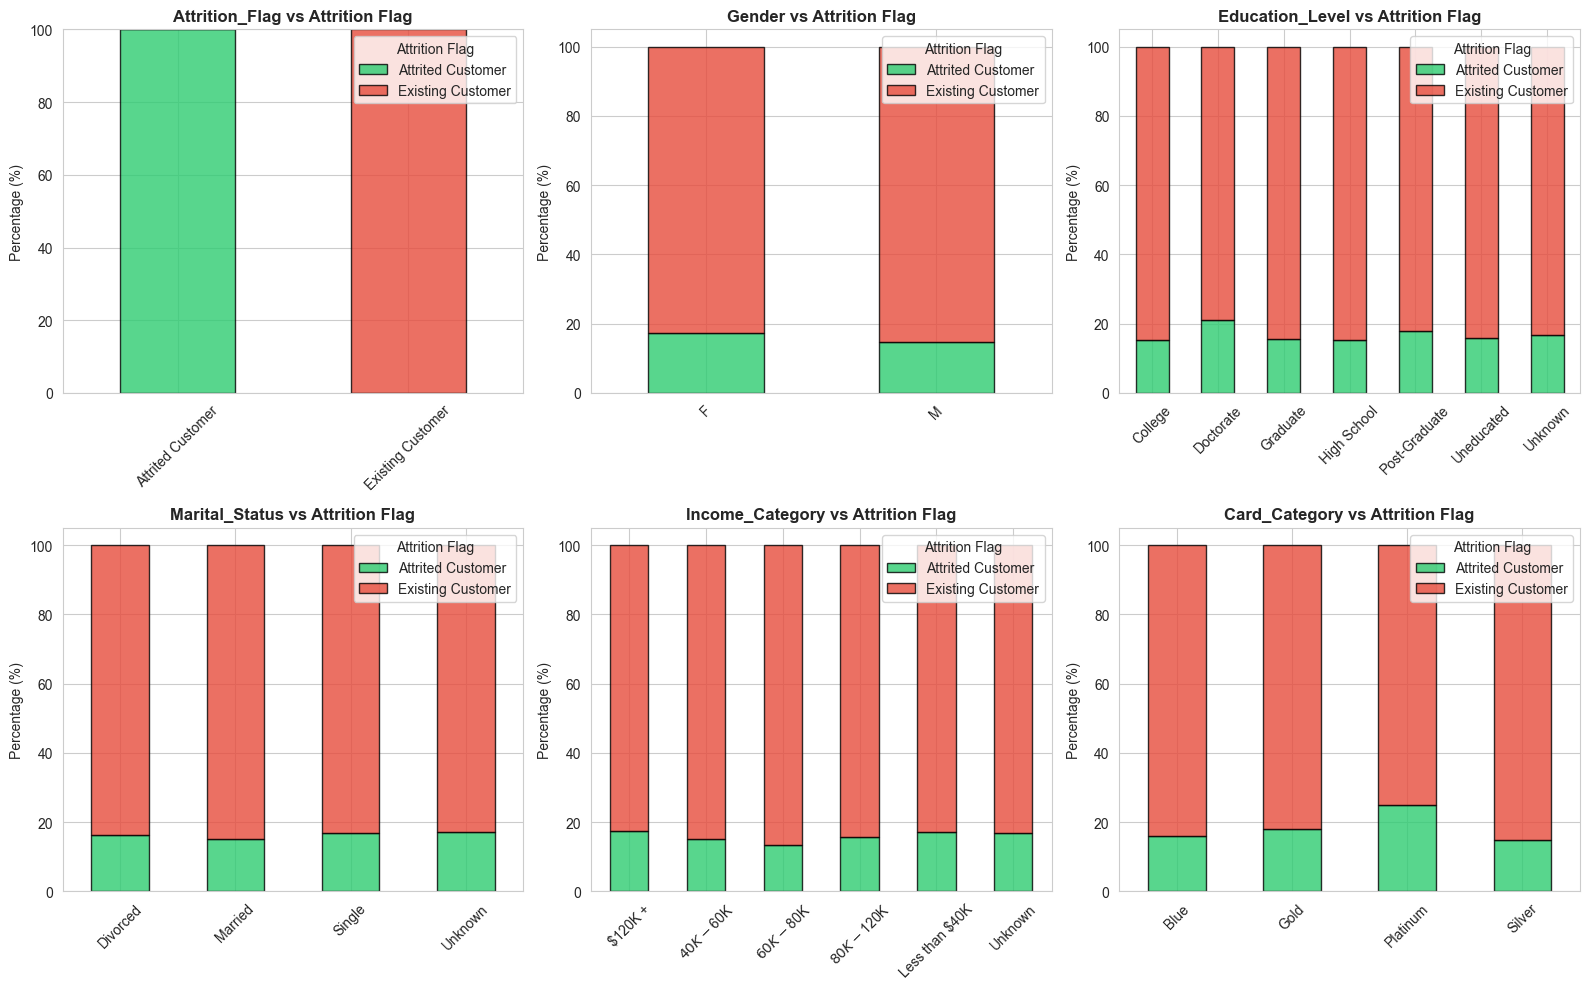

In [78]:
# Stacked bar charts for categorical features
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.ravel()

for idx, col in enumerate(cat_features):
    crosstab_pct = pd.crosstab(df[col], df['Attrition_Flag'], normalize='index') * 100
    crosstab_pct.plot(kind='bar', stacked=True, ax=axes[idx], color=['#2ecc71', '#e74c3c'], 
                      edgecolor='black', alpha=0.8)
    axes[idx].set_title(f'{col} vs Attrition Flag', fontsize=12, fontweight='bold')
    axes[idx].set_ylabel('Percentage (%)')
    axes[idx].set_xlabel('')
    axes[idx].legend(title='Attrition Flag', loc='upper right')
    axes[idx].tick_params(axis='x', rotation=45)

# Remove the last empty subplot
if len(cat_features) < len(axes):
    fig.delaxes(axes[-1])

plt.tight_layout()
plt.show()

## 6. Correlation Analysis

Correlation of Numerical Features with Attrition Flag:
Contacts_Count_12_mon       0.204491
Months_Inactive_12_mon      0.152449
Dependent_count             0.018991
Customer_Age                0.018203
Months_on_book              0.013687
Avg_Open_To_Buy            -0.000285
Credit_Limit               -0.023873
Total_Amt_Chng_Q4_Q1       -0.131063
Total_Relationship_Count   -0.150005
Total_Trans_Amt            -0.168598
Avg_Utilization_Ratio      -0.178410
Total_Revolving_Bal        -0.263053
Total_Ct_Chng_Q4_Q1        -0.290054
Total_Trans_Ct             -0.371403
Name: Attrition_Flag_Binary, dtype: float64


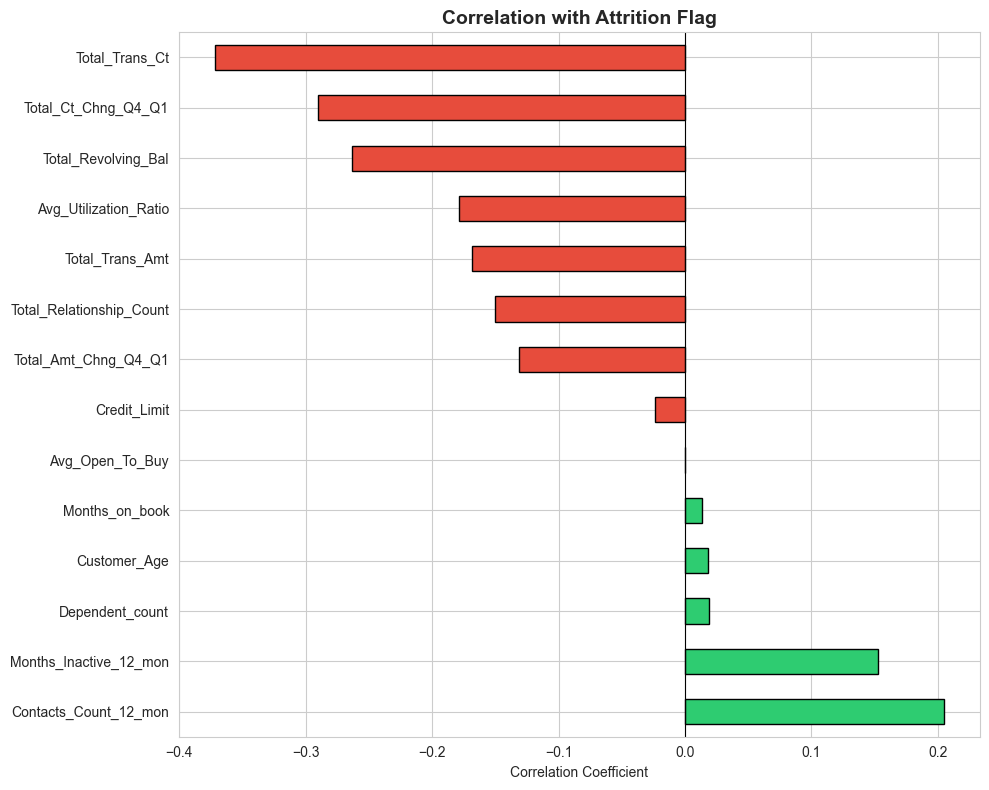

In [79]:
# Create a numeric version for correlation (encode Attrition_Flag)
df_numeric = df.copy()
df_numeric['Attrition_Flag_Binary'] = (df_numeric['Attrition_Flag'] == 'Attrited Customer').astype(int)

# Calculate correlation with target variable
correlation_with_target = df_numeric[numerical_cols + ['Attrition_Flag_Binary']].corr()['Attrition_Flag_Binary'].drop('Attrition_Flag_Binary')
correlation_with_target = correlation_with_target.sort_values(ascending=False)

print("Correlation of Numerical Features with Attrition Flag:")
print(correlation_with_target)

# Visualize correlation with target
fig, ax = plt.subplots(figsize=(10, 8))
colors = ['#e74c3c' if x < 0 else '#2ecc71' for x in correlation_with_target.values]
correlation_with_target.plot(kind='barh', ax=ax, color=colors, edgecolor='black')
ax.set_title('Correlation with Attrition Flag', fontsize=14, fontweight='bold')
ax.set_xlabel('Correlation Coefficient')
ax.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
plt.tight_layout()
plt.show()

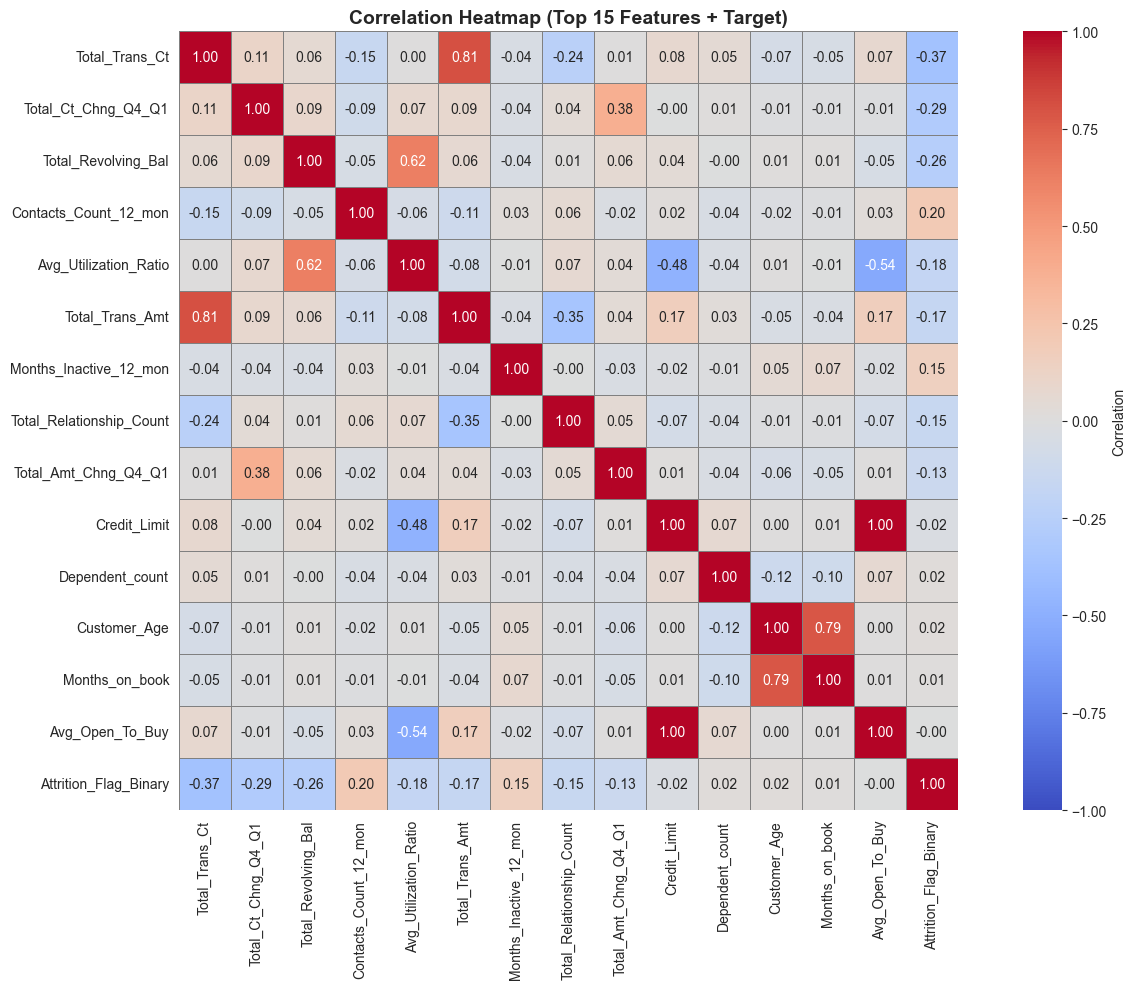

In [80]:
# Correlation heatmap (select top correlations for clarity)
fig, ax = plt.subplots(figsize=(14, 10))

# Select top features by absolute correlation
top_features = correlation_with_target.abs().nlargest(15).index.tolist()
correlation_matrix = df_numeric[top_features + ['Attrition_Flag_Binary']].corr()

sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, 
            cbar_kws={'label': 'Correlation'}, square=True, ax=ax, vmin=-1, vmax=1,
            linewidths=0.5, linecolor='gray')
ax.set_title('Correlation Heatmap (Top 15 Features + Target)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 7. Data Quality and Preparation Assessment

In [81]:
# Missing values, duplicates, and categorical consistency checks
print('DATA QUALITY CHECKS')
print('=' * 80)

missing_count = df.isnull().sum()
missing_pct = (missing_count / len(df) * 100).round(2)
missing_table = pd.DataFrame({'missing_count': missing_count, 'missing_pct': missing_pct})
missing_table = missing_table[missing_table['missing_count'] > 0].sort_values('missing_count', ascending=False)

if missing_table.empty:
    print('No missing values found in any column.')
else:
    print('\nColumns with missing values:')
    print(missing_table)

print(f'\nDuplicate rows: {df.duplicated().sum()}')

# Detect potential categorical inconsistencies (whitespace/case variants)
print('\nCategorical consistency diagnostics:')
categorical_quality = []
for col in categorical_cols:
    raw_unique = df[col].dropna().astype(str).nunique()
    normalized_unique = df[col].dropna().astype(str).str.strip().str.lower().nunique()
    unknown_count = (df[col].astype(str).str.strip().str.lower() == 'unknown').sum()
    categorical_quality.append({
        'feature': col,
        'raw_unique': raw_unique,
        'normalized_unique': normalized_unique,
        'possible_label_inconsistency': raw_unique != normalized_unique,
        'unknown_count': int(unknown_count)
    })

categorical_quality_df = pd.DataFrame(categorical_quality)
print(categorical_quality_df)

print('\nScaling readiness check (high variance/range features):')
range_table = pd.DataFrame({
    'min': df[numerical_cols].min(),
    'max': df[numerical_cols].max(),
    'std': df[numerical_cols].std(),
    'range': df[numerical_cols].max() - df[numerical_cols].min()
}).sort_values('range', ascending=False)
print(range_table.head(10))

DATA QUALITY CHECKS
No missing values found in any column.

Duplicate rows: 0

Categorical consistency diagnostics:
           feature  raw_unique  normalized_unique  \
0   Attrition_Flag           2                  2   
1           Gender           2                  2   
2  Education_Level           7                  7   
3   Marital_Status           4                  4   
4  Income_Category           6                  6   
5    Card_Category           4                  4   

   possible_label_inconsistency  unknown_count  
0                         False              0  
1                         False              0  
2                         False           1519  
3                         False            749  
4                         False           1112  
5                         False              0  

Scaling readiness check (high variance/range features):
                           min      max          std    range
Avg_Open_To_Buy            3.0  34516.0  9090.6853

## 8. Robust Univariate Statistics and Outlier Detection

In [82]:
# Robust central tendency/spread statistics for numerical attributes
stats_table = pd.DataFrame({
    'mean': df[numerical_cols].mean(),
    'median': df[numerical_cols].median(),
    'std': df[numerical_cols].std(),
    'skewness': df[numerical_cols].skew()
})
stats_table['mean_minus_median'] = (stats_table['mean'] - stats_table['median']).round(4)
stats_table = stats_table.sort_values('std', ascending=False)

print('ROBUST NUMERICAL SUMMARY (mean, median, std, skewness)')
print('=' * 80)
print(stats_table.round(4))

# Quick interpretation helper
skew_interpretation = pd.cut(
    stats_table['skewness'],
    bins=[-np.inf, -1, -0.5, 0.5, 1, np.inf],
    labels=['strong left skew', 'moderate left skew', 'approximately symmetric', 'moderate right skew', 'strong right skew']
)
print('\nSkewness interpretation:')
print(skew_interpretation.value_counts())

ROBUST NUMERICAL SUMMARY (mean, median, std, skewness)
                               mean    median        std  skewness  \
Avg_Open_To_Buy           7469.1396  3474.000  9090.6853    1.6617   
Credit_Limit              8631.9537  4549.000  9088.7767    1.6667   
Total_Trans_Amt           4404.0863  3899.000  3397.1293    2.0410   
Total_Revolving_Bal       1162.8141  1276.000   814.9873   -0.1488   
Total_Trans_Ct              64.8587    67.000    23.4726    0.1537   
Customer_Age                46.3260    46.000     8.0168   -0.0336   
Months_on_book              35.9284    36.000     7.9864   -0.1066   
Total_Relationship_Count     3.8126     4.000     1.5544   -0.1625   
Dependent_count              2.3462     2.000     1.2989   -0.0208   
Contacts_Count_12_mon        2.4553     2.000     1.1062    0.0110   
Months_Inactive_12_mon       2.3412     2.000     1.0106    0.6331   
Avg_Utilization_Ratio        0.2749     0.176     0.2757    0.7180   
Total_Ct_Chng_Q4_Q1          0.7122

IQR OUTLIER SUMMARY (1.5 * IQR)
                          outlier_count  outlier_pct
Credit_Limit                        984         9.72
Avg_Open_To_Buy                     963         9.51
Total_Trans_Amt                     896         8.85
Contacts_Count_12_mon               629         6.21
Total_Amt_Chng_Q4_Q1                396         3.91
Total_Ct_Chng_Q4_Q1                 394         3.89
Months_on_book                      386         3.81
Months_Inactive_12_mon              331         3.27
Customer_Age                          2         0.02
Total_Trans_Ct                        2         0.02
Total_Relationship_Count              0         0.00
Dependent_count                       0         0.00
Total_Revolving_Bal                   0         0.00
Avg_Utilization_Ratio                 0         0.00


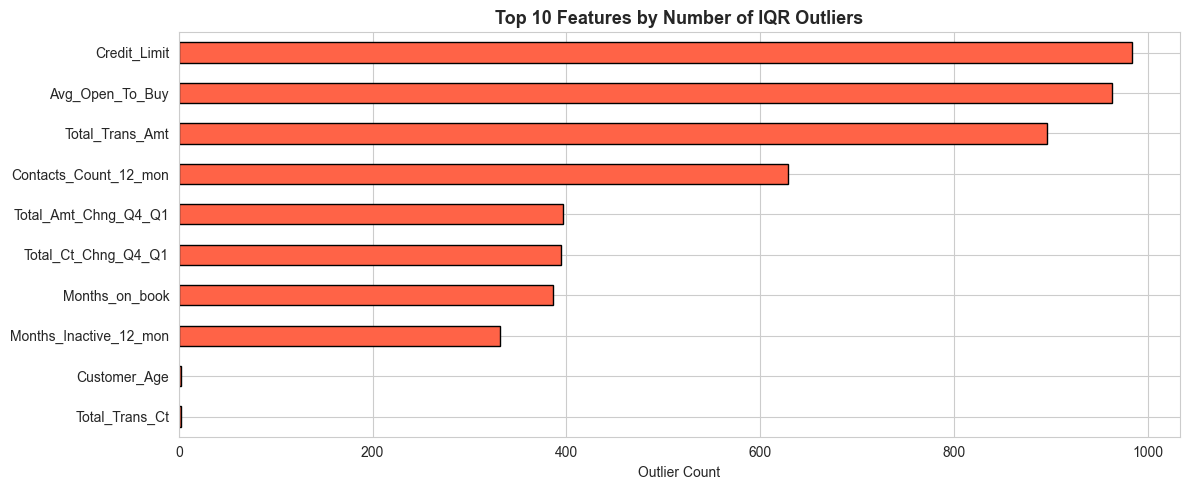

In [83]:
# IQR-based outlier detection (1.5 * IQR rule)
outlier_rows = {}
for col in numerical_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    mask = (df[col] < lower) | (df[col] > upper)
    outlier_rows[col] = int(mask.sum())

outlier_summary = pd.DataFrame({
    'outlier_count': pd.Series(outlier_rows),
})
outlier_summary['outlier_pct'] = (outlier_summary['outlier_count'] / len(df) * 100).round(2)
outlier_summary = outlier_summary.sort_values('outlier_count', ascending=False)

print('IQR OUTLIER SUMMARY (1.5 * IQR)')
print('=' * 80)
print(outlier_summary)

plt.figure(figsize=(12, 5))
outlier_summary.head(10)['outlier_count'].sort_values().plot(kind='barh', color='tomato', edgecolor='black')
plt.title('Top 10 Features by Number of IQR Outliers', fontsize=13, fontweight='bold')
plt.xlabel('Outlier Count')
plt.tight_layout()
plt.show()

## 9. Multivariate Relationships and Interaction Analysis

HIGH CORRELATION PAIRS (ABS CORR > 0.90)
       feature_1        feature_2  abs_correlation
92  Credit_Limit  Avg_Open_To_Buy         0.995981


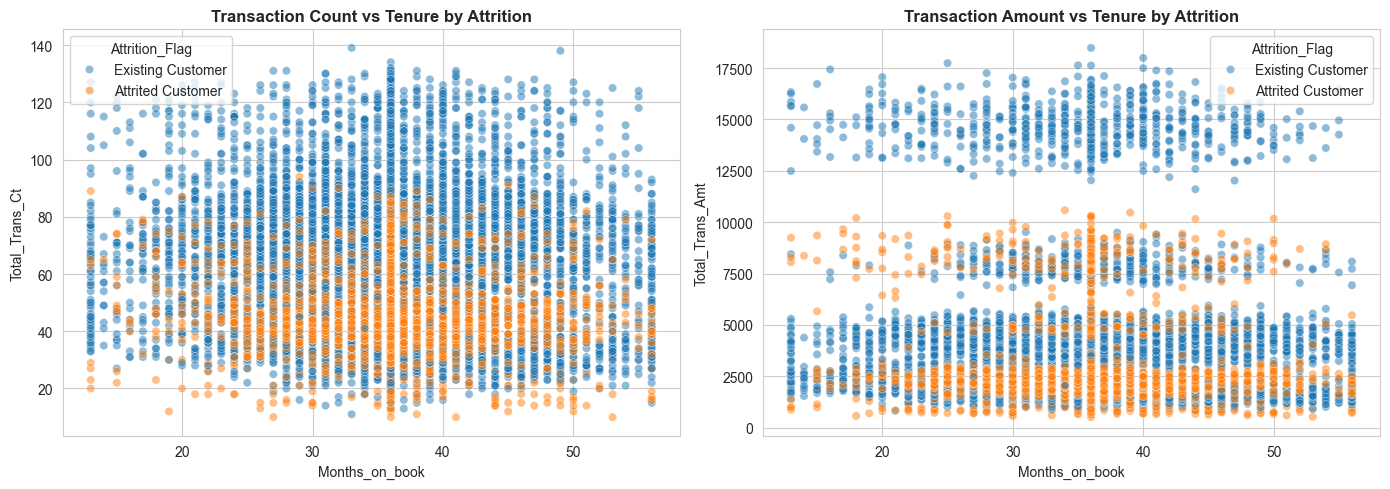

In [84]:
# Multicollinearity scan: identify highly correlated feature pairs (>|0.90|)
corr_matrix = df[numerical_cols].corr().abs()
upper_triangle = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

high_corr_pairs = (
    upper_triangle.stack()
    .reset_index()
    .rename(columns={'level_0': 'feature_1', 'level_1': 'feature_2', 0: 'abs_correlation'})
)
high_corr_pairs = high_corr_pairs[high_corr_pairs['abs_correlation'] > 0.90].sort_values('abs_correlation', ascending=False)

print('HIGH CORRELATION PAIRS (ABS CORR > 0.90)')
print('=' * 80)
if high_corr_pairs.empty:
    print('No feature pairs above 0.90 found.')
else:
    print(high_corr_pairs)

# Scatter plot interaction requested: transaction behavior vs tenure
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(
    data=df,
    x='Months_on_book',
    y='Total_Trans_Ct',
    hue='Attrition_Flag',
    alpha=0.5,
    ax=axes[0]
)
axes[0].set_title('Transaction Count vs Tenure by Attrition', fontsize=12, fontweight='bold')

sns.scatterplot(
    data=df,
    x='Months_on_book',
    y='Total_Trans_Amt',
    hue='Attrition_Flag',
    alpha=0.5,
    ax=axes[1]
)
axes[1].set_title('Transaction Amount vs Tenure by Attrition', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

## 10. Feature Engineering Foundations

In [85]:
# Candidate engineered features for downstream modeling
fe_df = df.copy()

# Example domain-inspired features
fe_df['Tenure_Years'] = (fe_df['Months_on_book'] / 12).round(2)
fe_df['Transactions_Per_Month'] = (fe_df['Total_Trans_Ct'] / fe_df['Months_on_book'].replace(0, np.nan)).fillna(0)
fe_df['Amount_Per_Transaction'] = (fe_df['Total_Trans_Amt'] / fe_df['Total_Trans_Ct'].replace(0, np.nan)).fillna(0)
fe_df['Loyalty_Score'] = (
    0.4 * fe_df['Total_Relationship_Count'] +
    0.3 * fe_df['Transactions_Per_Month'] +
    0.3 * fe_df['Tenure_Years']
)

# Discretization examples
fe_df['Age_Bucket'] = pd.cut(
    fe_df['Customer_Age'],
    bins=[17, 30, 45, 60, 100],
    labels=['Young Adult', 'Adult', 'Mature Adult', 'Senior']
)
fe_df['Tenure_Bucket'] = pd.cut(
    fe_df['Months_on_book'],
    bins=[0, 24, 48, 120],
    labels=['New', 'Established', 'Long-Term']
)

print('FEATURE ENGINEERING PREVIEW')
print('=' * 80)
print(fe_df[['Customer_Age', 'Months_on_book', 'Total_Trans_Ct', 'Total_Trans_Amt',
             'Tenure_Years', 'Transactions_Per_Month', 'Amount_Per_Transaction',
             'Loyalty_Score', 'Age_Bucket', 'Tenure_Bucket']].head())

print('\nNotes:')
print('- Temporal feature extraction (year/month/day) is not applicable because no date columns are available in this dataset.')
print('- These engineered features are candidates; validate with cross-validation and leakage checks before final model use.')

FEATURE ENGINEERING PREVIEW
   Customer_Age  Months_on_book  Total_Trans_Ct  Total_Trans_Amt  \
0            45              39              42             1144   
1            49              44              33             1291   
2            51              36              20             1887   
3            40              34              20             1171   
4            40              21              28              816   

   Tenure_Years  Transactions_Per_Month  Amount_Per_Transaction  \
0          3.25                1.076923               27.238095   
1          3.67                0.750000               39.121212   
2          3.00                0.555556               94.350000   
3          2.83                0.588235               58.550000   
4          1.75                1.333333               29.142857   

   Loyalty_Score    Age_Bucket Tenure_Bucket  
0       3.298077         Adult   Established  
1       3.726000  Mature Adult   Established  
2       2.666667  M

## 11. Summary & Key Insights

In [86]:
print("=" * 80)
print("DATA EXPLORATION SUMMARY")
print("=" * 80)

print(f"\nDATASET OVERVIEW:")
print(f"  - Total Records: {len(df):,}")
print(f"  - Total Features: {df.shape[1]}")
print(f"  - Numerical Features: {len(numerical_cols)}")
print(f"  - Categorical Features: {len(cat_features)}")

print(f"\nTARGET VARIABLE (Attrition_Flag):")
attrition_counts = df['Attrition_Flag'].value_counts()
for label, count in attrition_counts.items():
    pct = (count / len(df)) * 100
    print(f"  - {label}: {count:,} ({pct:.2f}%)")

print(f"\nDATA QUALITY:")
print(f"  - Missing Values: {df.isnull().sum().sum()}")
print(f"  - Duplicates: {df.duplicated().sum()}")

print(f"\nTOP 10 FEATURES CORRELATED WITH ATTRITION:")
for idx, (feature, corr) in enumerate(correlation_with_target.head(10).items(), 1):
    direction = "Increases" if corr > 0 else "Decreases"
    print(f"  {idx:2d}. {feature:40s} | Correlation: {corr:7.4f} | {direction} attrition")

print(f"\nMODELING PREPARATION RECOMMENDATIONS:")
print("  1. Address class imbalance using class weights or resampling (SMOTE)")
print("  2. Scale numerical features (StandardScaler/MinMaxScaler) for distance-based models")
print("  3. Encode categorical variables and handle 'Unknown' consistently")
print("  4. Review high-correlation feature pairs to reduce multicollinearity")
print("  5. Treat outliers carefully: cap/winsorize or keep if business-valid high-value customers")
print("  6. Evaluate engineered features (Loyalty_Score, transaction intensity, buckets) via cross-validation")
print("=" * 80)

DATA EXPLORATION SUMMARY

DATASET OVERVIEW:
  - Total Records: 10,127
  - Total Features: 23
  - Numerical Features: 14
  - Categorical Features: 6

TARGET VARIABLE (Attrition_Flag):
  - Existing Customer: 8,500 (83.93%)
  - Attrited Customer: 1,627 (16.07%)

DATA QUALITY:
  - Missing Values: 0
  - Duplicates: 0

TOP 10 FEATURES CORRELATED WITH ATTRITION:
   1. Contacts_Count_12_mon                    | Correlation:  0.2045 | Increases attrition
   2. Months_Inactive_12_mon                   | Correlation:  0.1524 | Increases attrition
   3. Dependent_count                          | Correlation:  0.0190 | Increases attrition
   4. Customer_Age                             | Correlation:  0.0182 | Increases attrition
   5. Months_on_book                           | Correlation:  0.0137 | Increases attrition
   6. Avg_Open_To_Buy                          | Correlation: -0.0003 | Decreases attrition
   7. Credit_Limit                             | Correlation: -0.0239 | Decreases attritio